# Merging and Joining

## *Reading Week*  [![Open In Colab](https://github.com/oballinger/BASC0005/blob/main/colab-badge.png?raw=1)](https://colab.research.google.com/github/oballinger/BASC0005/blob/main/notebooks/RW.%20Merging%20and%20Joining.ipynb)

We often want to combine data about the same things from different sources: GDP and life expectancy for each country, or a city's population and the country it belongs to. This self-study notebook covers the two ways of combining tables in pandas: **stacking** them (`concat`) and **joining** them on a shared key (`merge`). It also covers the ways that joins silently go wrong.

Joins are also the basis of next week's topic: a **spatial join** attaches data to points or polygons based on *where* they are, rather than on a shared name.

### Aims
- Stack dataframes with `concat`, and understand what happens to the index
- Join dataframes with `merge`: inner, left, right and outer joins
- Handle one-to-many joins on real UN data
- Diagnose failed joins: duplicate keys, mismatched names, silently dropped rows

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

rng = np.random.default_rng(42)   # fixed seed, so everyone gets the same "random" numbers

## Adding new observations: `concat`

We start with small made-up tables, because they make it easy to see what is going on. Here are some (fictitious, anonymised) measurements of people:

In [2]:
cols = ["units of alcohol", "cigarettes smoked", "sleep per night", "height", "BMI"]
people1 = pd.DataFrame(5 + rng.standard_normal((5, 5)), columns=cols)
people2 = pd.DataFrame(5 + rng.standard_normal((3, 5)), columns=cols)
people1

,units of alcohol,cigarettes smoked,sleep per night,height,BMI
0,5.304717,3.960016,5.750451,5.940565,3.048965
1,3.697820,5.127840,4.683757,4.983199,4.146956
2,5.879398,5.777792,5.066031,6.127241,5.467509
3,4.140708,5.368751,4.041117,5.878450,4.950074
4,4.815138,4.319070,6.222541,4.845471,4.571672


In [3]:
people2

,units of alcohol,cigarettes smoked,sleep per night,height,BMI
0,4.647866,5.532309,5.365444,5.412733,5.430821
1,7.141648,4.593585,4.487757,4.186227,5.615979
2,6.128972,4.886053,4.159844,4.175519,5.650593


Both tables have the same columns, so we can stack one on top of the other with `concat` (short for *concatenate*, "chain together"):

In [4]:
people3 = pd.concat([people1, people2])
people3

,units of alcohol,cigarettes smoked,sleep per night,height,BMI
0,5.304717,3.960016,5.750451,5.940565,3.048965
1,3.697820,5.127840,4.683757,4.983199,4.146956
2,5.879398,5.777792,5.066031,6.127241,5.467509
3,4.140708,5.368751,4.041117,5.878450,4.950074
4,4.815138,4.319070,6.222541,4.845471,4.571672
0,4.647866,5.532309,5.365444,5.412733,5.430821
1,7.141648,4.593585,4.487757,4.186227,5.615979
2,6.128972,4.886053,4.159844,4.175519,5.650593


### What is the problem above?

Look at the index. What would `people3.loc[0]` return? Try it.

In [5]:
# your code here

`ignore_index=True` throws away the old indices and numbers the rows afresh. Use it when the index carries no information:

In [6]:
people4 = pd.concat([people1, people2], ignore_index=True)
people4

,units of alcohol,cigarettes smoked,sleep per night,height,BMI
0,5.304717,3.960016,5.750451,5.940565,3.048965
1,3.697820,5.127840,4.683757,4.983199,4.146956
2,5.879398,5.777792,5.066031,6.127241,5.467509
3,4.140708,5.368751,4.041117,5.878450,4.950074
4,4.815138,4.319070,6.222541,4.845471,4.571672
5,4.647866,5.532309,5.365444,5.412733,5.430821
6,7.141648,4.593585,4.487757,4.186227,5.615979
7,6.128972,4.886053,4.159844,4.175519,5.650593


When the index **does** mean something (here, a city name), keep it: city names do not clash the way row numbers do.

In [7]:
city_cols = ["area", "population", "mean temperature", "elevation", "annual rainfall"]
df1 = pd.DataFrame(5 + rng.standard_normal((5, 5)), columns=city_cols,
                   index=["London", "Paris", "Beijing", "Medellin", "Port Elizabeth"])
df2 = pd.DataFrame(5 + rng.standard_normal((3, 5)), columns=city_cols,
                   index=["Mumbai", "Sydney", "Boston"])
df3 = pd.concat([df1, df2])
df3

,area,population,mean temperature,elevation,annual rainfall
London,5.743254,5.543154,4.334490,5.232161,5.116686
Paris,5.218689,5.871429,5.223596,5.678914,5.067579
Beijing,5.289119,5.631288,3.542844,4.680329,4.529627
Medellin,4.361122,4.724858,6.494941,4.134169,5.968278
Port Elizabeth,3.317130,4.665115,5.162753,5.586222,5.711227
Mumbai,5.793347,4.651275,4.537648,5.857976,4.808696
Sydney,3.724314,3.866713,4.080548,5.497161,5.142426
Boston,5.690485,4.572747,5.158540,5.625590,4.690653


### Exercise: concat continued

Create a dataframe with made-up values for New York, Tokyo, Manila and Budapest, and concatenate it with `df3` into a new dataframe `df`. Then check that its index has no duplicates: `df.index.is_unique`.

In [8]:
# your code here

## Adding new attributes: `merge`

What if we have **different variables** about the **same** cities? Then we want to put the tables side by side, matching rows by city, not by position.

In [9]:
df4 = pd.DataFrame(5 + rng.standard_normal((5, 3)),
                   columns=["mean house price", "median income", "walkability score"],
                   index=["Paris", "Port Elizabeth", "Beijing", "Medellin", "London"])
df4

,mean house price,median income,walkability score
Paris,5.456775,4.338074,4.636946
Port Elizabeth,4.618262,3.804160,5.486972
Beijing,4.530598,5.012494,5.480747
Medellin,5.446531,5.665385,4.901515
London,4.576702,4.920282,3.312666


`df4` is in a different order from `df1`. Joining **on the index** matches rows by label, so the order does not matter:

In [10]:
df_joined = df1.merge(df4, left_index=True, right_index=True)
df_joined

,area,population,mean temperature,elevation,annual rainfall,mean house price,median income,walkability score
London,5.743254,5.543154,4.334490,5.232161,5.116686,4.576702,4.920282,3.312666
Paris,5.218689,5.871429,5.223596,5.678914,5.067579,5.456775,4.338074,4.636946
Beijing,5.289119,5.631288,3.542844,4.680329,4.529627,4.530598,5.012494,5.480747
Medellin,4.361122,4.724858,6.494941,4.134169,5.968278,5.446531,5.665385,4.901515
Port Elizabeth,3.317130,4.665115,5.162753,5.586222,5.711227,4.618262,3.804160,5.486972


`df1` is the **left** table (the one whose `.merge` method we call) and `df4` is the **right** table (the argument).

## Mismatched records: the four joins

Now suppose the second table covers only some of our cities, plus one that is not in `df1`:

In [11]:
df5 = pd.DataFrame(5 + rng.standard_normal((3, 3)),
                   columns=["mean house price", "median income", "walkability score"],
                   index=["London", "Paris", "Glasgow"])
df5

,mean house price,median income,walkability score
London,3.552888,3.677300,4.002753
Paris,5.399774,4.094521,4.621837
Glasgow,6.299228,4.643736,5.737516


### Exercise

Without running any code: how many cities appear in (a) both `df1` and `df5`, (b) only `df1`, (c) only `df5`?

### Inner join

An **inner** join keeps only the keys that appear in **both** tables. It is the default for `merge`.

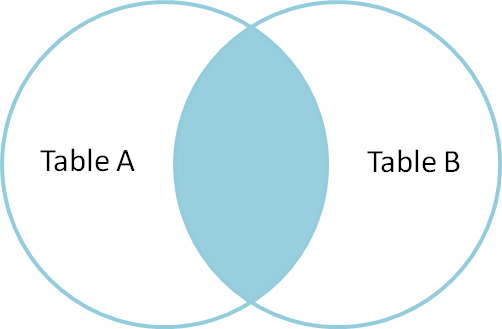

In [12]:
Image("https://s3.eu-west-2.amazonaws.com/qm2/wk3/inner.png")

(Image from [Coding Horror: a visual explanation of SQL joins](https://blog.codinghorror.com/a-visual-explanation-of-sql-joins/))

In [13]:
df1.merge(df5, left_index=True, right_index=True, how="inner")

,area,population,mean temperature,elevation,annual rainfall,mean house price,median income,walkability score
London,5.743254,5.543154,4.334490,5.232161,5.116686,3.552888,3.677300,4.002753
Paris,5.218689,5.871429,5.223596,5.678914,5.067579,5.399774,4.094521,4.621837


### Left join

A **left** join keeps **every** row of the left table and attaches matching data from the right. Where there is no match, the right-hand columns are `NaN` (Not a Number: missing).

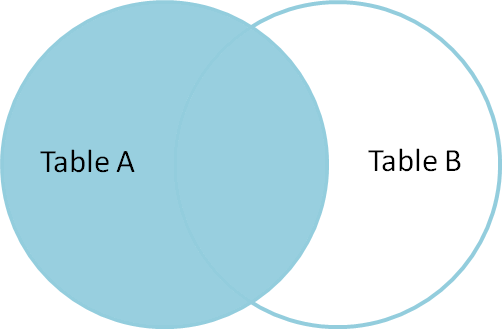

In [14]:
Image("https://s3.eu-west-2.amazonaws.com/qm2/wk3/left.png")

`indicator=True` adds a `_merge` column that tells you where each row came from. **Use it whenever you join real data**: it is the quickest way to see what did and did not match.

In [15]:
df1.merge(df5, left_index=True, right_index=True, how="left", indicator=True)

,area,population,mean temperature,elevation,annual rainfall,mean house price,median income,walkability score,_merge
London,5.743254,5.543154,4.334490,5.232161,5.116686,3.552888,3.677300,4.002753,both
Paris,5.218689,5.871429,5.223596,5.678914,5.067579,5.399774,4.094521,4.621837,both
Beijing,5.289119,5.631288,3.542844,4.680329,4.529627,NaN,NaN,NaN,left_only
Medellin,4.361122,4.724858,6.494941,4.134169,5.968278,NaN,NaN,NaN,left_only
Port Elizabeth,3.317130,4.665115,5.162753,5.586222,5.711227,NaN,NaN,NaN,left_only


### Exercise: right and outer joins

Do a `how="right"` and a `how="outer"` join of `df1` and `df5`, with `indicator=True`. For each one, explain which rows are kept and why. Which join type would you use if losing *any* row were unacceptable?

In [16]:
# your code here

## One-to-many joins: real UN data

So far each key appeared once in each table (**one-to-one**). Often it does not. For example, we have population data for **cities**, and life expectancy for **countries**. To give each city its country's life expectancy, many cities must match one country: a **many-to-one** join.

The data comes from [UNdata](http://data.un.org/Data.aspx?d=POP&f=tableCode%3A240) (city populations, 2012-2014) and the World Bank's World Development Indicators via UNdata (life expectancy). Start with city populations:

In [17]:
base = "https://s3.eu-west-2.amazonaws.com/qm2/wk3/"
city_pop = pd.read_csv(base + "UN_Cities_1214_population.csv", encoding="latin1")
print(city_pop.shape)
city_pop.head()

(3796, 10)


,Year,Area,Sex,City,City type,Record Type,Reliability,Source Year,Value,Value Footnotes
0,2013,Total,Both Sexes,MARIEHAMN,City proper,Estimate - de jure,"Final figure, complete",2014,11370.0,NaN
1,2013,Total,Male,MARIEHAMN,City proper,Estimate - de jure,"Final figure, complete",2014,5445.0,NaN
2,2013,Total,Female,MARIEHAMN,City proper,Estimate - de jure,"Final figure, complete",2014,5925.0,NaN
3,2012,Total,Both Sexes,MARIEHAMN,City proper,Estimate - de jure,"Final figure, complete",2013,11304.5,NaN
4,2012,Total,Male,MARIEHAMN,City proper,Estimate - de jure,"Final figure, complete",2013,5408.0,NaN


This is long-format data with several rows per city (years × sexes). Keep one year and both sexes, and drop the footnotes column. (Returning a new dataframe is safer than editing in place with `inplace=True`.)

In [18]:
city_pop = city_pop[(city_pop["Sex"] == "Both Sexes") & (city_pop["Year"] == 2012)]
city_pop = city_pop.drop(columns="Value Footnotes").rename(columns={"Value": "population"})
print(city_pop.shape)
city_pop.head()

(1230, 9)


,Year,Area,Sex,City,City type,Record Type,Reliability,Source Year,population
3,2012,Total,Both Sexes,MARIEHAMN,City proper,Estimate - de jure,"Final figure, complete",2013,11304.5
33,2012,Total,Both Sexes,BahÌ_a Blanca-Cerri,Urban agglomeration,Estimate - de facto,"Final figure, complete",2012,314948.0
34,2012,Total,Both Sexes,BUENOS AIRES,Urban agglomeration,Estimate - de facto,"Final figure, complete",2012,13242375.0
35,2012,Total,Both Sexes,Catamarca,Urban agglomeration,Estimate - de facto,"Final figure, complete",2012,212174.0
36,2012,Total,Both Sexes,Comodoro Rivadavia-Rada Tilly,Urban agglomeration,Estimate - de facto,"Final figure, complete",2012,145475.0


The population table does not say which country each city is in. A second file does:

In [19]:
city_c = pd.read_csv(base + "UN_Cities_1214_country.csv", encoding="latin1")
print(city_c.shape)
city_c.head()

(1230, 2)


,Country or Area,City
0,íland Islands,MARIEHAMN
1,Argentina,Bahí_a Blanca-Cerri
2,Argentina,BUENOS AIRES
3,Argentina,Catamarca
4,Argentina,Comodoro Rivadavia-Rada Tilly


(`íland Islands` should be *Åland Islands*: a character-encoding error, another kind of dirty data. It happens when a file saved in one encoding is read as another.)

The key is now an ordinary **column**, not the index, so we use `on=` (or `left_on=`/`right_on=` if the columns have different names in the two tables):

In [20]:
cities = city_pop.merge(city_c, on="City", how="left", indicator=True)
print(len(city_pop), "rows before,", len(cities), "rows after")
cities["_merge"].value_counts()

1230 rows before, 1498 rows after


_merge
both          1401
left_only       97
right_only       0
Name: count, dtype: int64

### Exercise: spot the problem

A left join should keep every row of the left table **exactly once**. We started with 1,230 rows and ended with more.

1. Find the cause. (Hint: `city_c["City"].duplicated().sum()`, and `city_c.duplicated().sum()` for completely identical rows.) What does a join do when a key appears twice in the right-hand table?
2. Remove the exact duplicates (`drop_duplicates()`) and redo the merge, this time passing `validate="many_to_one"`, which raises an error if the right-hand keys are not unique. It still fails. Read the error message: which city is the problem, and in which two countries is it? What would a join on the name alone do to it, and what would be a better key?
3. Now look at the 97 `left_only` rows: `cities[cities["_merge"] == "left_only"]["City"]`. What do the unmatched names have in common? Compare the same city in the two files (for example the Argentinian city of Bahía Blanca). Why can't pandas match them?
4. `city_pop` itself also has repeated city names (`city_pop["City"].duplicated().sum()`). Look at the `City type` column: what are the two kinds of row, and why would adding them up double-count people?

In [21]:
# your code here

## Life expectancy by country

In [22]:
life = pd.read_csv(base + "UN_Life_all.csv")
life.head()

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2012,60.509122,NaN
1,Afghanistan,2011,60.065366,NaN
2,Afghanistan,2010,59.600098,NaN
3,Afghanistan,2009,59.112341,NaN
4,Afghanistan,2008,58.607098,NaN


### Exercise: clean, then join

1. Keep only 2012, drop the `Value Footnotes` column and rename `Value` to `life_expectancy`.
2. Before you clean it: how many rows does `life` have per country? What would happen to the number of rows if you merged the **uncleaned** `life` onto `cities`?
3. Merge the cleaned table onto your de-duplicated `cities` (the country column is `Country or Area` in both), using `how="left"`, `validate="many_to_one"` and `indicator="life_match"` (a new name, because `cities` already has a `_merge` column).
4. Make a scatter plot of city population (log scale) against life expectancy.
5. How many cities failed to match? List the unmatched **countries** with `value_counts()`. One country accounts for most of them. Find its name in `life` and in `cities`, and fix the mismatch (hint: `.replace({...})` on one of the columns).

Joining on names is fragile: "United States" and "United States of America" are different strings. Where possible, join on **codes** (ISO3 country codes, ONS area codes, vessel MMSI numbers) instead.

In [23]:
# your code here

## Looking ahead: spatial joins

Next week we join on **location** instead of names. `geopandas.sjoin(points, polygons, predicate="within")` attaches to each point (a ship, a sensor, an event) the attributes of the polygon (a country, an ocean region, a borough) that contains it. The logic is the same as today's: there is a left and a right table and a `how=` argument, and the same questions apply: which rows failed to match, and did any row match more than once?